# 7. Agentic Workload (2): 서비스하기

글쓴이: [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)), [Claude Code](https://claude.com/claude-code) 🤖

{doc}`06-agentic-workloads`에서는 agent 트래픽이 *무엇인지*를 보았습니다. 과제 하나당 서로
의존하는 수십 개의 요청, turn마다 자라는 prompt, 그리고 tool이 도는 동안의 긴 빈틈.
이번 강의는 같은 두 trace를 GPU에 올립니다. 그 반복되는 prompt 텍스트 중 prefix cache가
실제로 아껴 주는 것은 얼마나 될까요? 그것이 과제를 기다리는 사람에게는 얼마만큼의 값어치가
있을까요? 그리고 그래도 과제가 느리다면, 그 시간은 어디로 간 걸까요?

:::{admonition} 학습 목표
- 실제 agent trace에서 KV cache hit rate를 측정하고, hit가 어디서 오는지, 그리고 단일
  agent와 multi-agent 시스템이 왜 다른지 설명할 수 있다.
- TTFT가 6배 좋아져도 과제 시간은 4분의 1만 줄어들 수 있는 이유를 설명할 수 있다.
- 과제 하나를 prefill, decode, queueing, tool 시간으로 쪼개고, 그중 serving system이 손댈 수
  있는 것이 무엇인지 말할 수 있다.
:::

## 준비

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/faculty/kvm6242/.llm-systems-wo-gpus/backend


지난 강의와 같은 OWL 과제 24개, 그리고 MiroThinker 과제 24개를 불러옵니다. 이번에는 둘 다
simulation해야 하므로 둘 다 상한을 둡니다. `gaia_sessions`는 요청 하나라도 `max_tokens`보다
길면 그 과제를 건너뜁니다. 이 강의의 runtime predictor가 거기까지만 학습되었기 때문입니다.
OWL은 기본 상한(16,384 token)으로 충분하지만, MiroThinker의 요청은 훨씬 길어서 32,768까지
허용했고 그래도 가장 큰 과제들은 빠집니다. MiroThinker 숫자를 읽을 때 이 점을 기억하세요.
가장 무거운 session들은 표본에 없습니다.

In [2]:
sessions = lsg.gaia_sessions(num_sessions=24, seed=0)                    # OWL, multi-agent
miro = lsg.gaia_sessions(num_sessions=24, seed=0, agent="mirothinker", max_tokens=32768)
print(f"OWL: {len(sessions)} requests, MiroThinker: {len(miro)} requests")

OWL: 673 requests, MiroThinker: 356 requests


## 재사용 가능한 부분은 얼마나 되나?

이제 이 trace들이 prefix cache hit를 얼마나 얻는지 봅시다.
이런 agentic trace는 prefix를 많이 재사용할까요?
먼저, 완벽하고 무한히 큰 prefix cache라면 어떻게 될지를 5강의 규칙 그대로 계산해 봅니다.
꽉 찬 16 token block마다 사슬 해시를 구하고, 각 prompt의 앞쪽 block 중 몇 개가 전에 본
것인지 셉니다.

In [3]:
def ideal_hit_rate(df, block=16):
    seen, hits, total = set(), 0, 0
    for _, r in df.iterrows():
        ids = json.loads(r.token_ids)
        h, hashes = None, []
        for b in range(len(ids) // block):           # name every full block
            h = hash((h, tuple(ids[b * block:(b + 1) * block])))
            hashes.append(h)
        matched = 0
        for name in hashes[:r.num_prefill_tokens // block]:   # walk the prompt
            if name not in seen:
                break
            matched += 1
        hits += matched * block
        total += r.num_prefill_tokens
        seen.update(hashes)                          # the prompt and the output are cached
    return hits / total

print(f"OWL         : {ideal_hit_rate(sessions):.1%}")
print(f"MiroThinker : {ideal_hit_rate(miro):.1%}")

OWL         : 61.1%


MiroThinker : 71.5%


OWL은 전체 prompt token의 약 60%, MiroThinker는 약 71%가 전에 계산된 적이 있어 prefix
caching의 혜택을 받을 수 있습니다. OWL의 값은 GAIATrace 논문
([Kim et al., IISWC '26](https://arxiv.org/abs/2606.01725))과 대체로 들어맞습니다.
이 값들이 높은 이유는 system prompt가 길고, agent들이 자기 과거 대화 기록을 자주 들여다보기
때문입니다. 5강의 multi-turn chat과 비슷하죠.

다만 둘 다 다른 논문들(예: Agentic AI Workload Characteristics,
[Yuan et al., IISWC '26](https://arxiv.org/abs/2605.26297))이 보고한 값보다는 낮습니다.
그쪽은 87--99% 정도였습니다.
MiroThinker를 역할별로 쪼개 보면 그 차이가 어디서 오는지 보입니다.

In [4]:
pd.DataFrame({role: {"prompt tokens": g.num_prefill_tokens.sum(),
                     "ideal hit rate": ideal_hit_rate(g)}
              for role, g in miro.groupby("role")}).round(3)

,main,summarizer
prompt tokens,2749549.000,600669.000
ideal hit rate,0.869,0.006


Main agent만 보면 87%로, 저 논문들이 보고한 범위 안에 정확히 들어옵니다. 오직 뒤에 덧붙이기만
하는 대화 하나이므로, 거의 모든 prompt가 이전 prompt에 조금 더한 것이기 때문입니다.
요약기는 약 0%입니다. 호출마다 같은 짧은 지시문 뒤에 서로 다른 스크랩 페이지가 붙으니
재사용할 것이 지시문밖에 없습니다. 그런데 그 호출들이 prompt token의 5분의 1을 차지하면서
시스템 전체 값을 71%로 끌어내립니다. Main agent만 계측한 논문이라면 바로 이 같은 시스템을
두고 87%라고 보고했을 것입니다.

OWL은 그보다 더 낮은 60%인데, 이유는 비슷합니다. Multi-agent 시스템인 OWL은 여러 sub-agent를
돌리고, 각자가 자기 system prompt로 자기 대화를 시작하므로 서로 간의 공유가 제한적입니다.

참고로 Mooncake
([Qin et al., FAST '25](https://arxiv.org/abs/2407.00079))는 Kimi chatbot에 오는 tool/agent
성격 트래픽에서 약 59%, 일반 대화에서 약 40%를 보고했습니다.
다시 말하지만, agentic 시스템을 어떻게 설계했느냐가 prefix cache hit rate를 크게 좌우합니다.
agentic 시스템의 올바른 설계가 무엇인지 아직 합의가 없으므로, 이 숫자는 합의가 모일 때까지
앞으로도 계속 흔들릴 것입니다.

:::{admonition} 직접 해보기
:class: exercise
1. `lsg.gaia_sessions`를 `seed=1`, `num_sessions=48`로 다시 돌리고 두 시스템의 이상적인 hit
   rate를 다시 계산해 보세요. 표본이 바뀌어도 얼마나 안정적인가요? 이는 하나의 trace에 맞춰
   시스템을 튜닝하는 것에 대해 무엇을 말해 주나요?
2. OWL에 대해서도 같은 역할별 분해를 해 보세요. 가장 보기 좋은 hit rate를 발표하고 싶다면
   어느 worker를 인용하겠습니까? 그리고 진짜 문제는 어느 쪽인가요?
:::

## Trace를 서비스해 보기

이제 trace를 simulator에 넣어 봅시다.
여기서는 간단히, 어떤 sub-agent가 냈든 기록 당시 어떤 모델이 처리했든, 모든 요청이 A100 두
장 위의 Qwen2.5-32B replica 하나로 간다고 가정합니다. 3–5강과 같은 설정이고, prefix cache는
그 replica의 GPU 메모리에 있습니다.
Tool latency는 trace에서 가져오므로, turn은 실제 tool이 걸린 만큼 정확히 기다립니다.
`lsg.gaia_trace`가 token id와 의존 그래프를 포함해 simulator 형식으로 trace를 써 주고,
그래서 turn *k+1*은 turn *k*가 끝나고 그 tool 호출이 돌아온 뒤에야 풀립니다. 새 과제는 10초에
하나씩 replica 하나로 보냅니다.

사용자는 과제 전체를 기다리므로 **task 완료 시간**을 잽니다. Session의 첫 요청이 도착한
순간부터 마지막 요청이 끝나는 순간까지, tool 시간까지 포함해서요.

In [5]:
def task_times(result):
    """Wall-clock time of each session, from its first arrival to its last completion."""
    q = result.requests.assign(session=lambda d: d["Request Id"] // 1000,
                               done=lambda d: d["request_arrived_at"] + d["request_e2e_time"])
    return q.groupby("session").apply(
        lambda d: d["done"].max() - d["request_arrived_at"].min(), include_groups=False)

out = {}
for name, df in [("OWL", sessions), ("MiroThinker", miro)]:
    trace = lsg.gaia_trace(df, name=name.lower())
    for pc in (False, True):
        r = lsg.simulate(**SYSTEM, trace=trace, num_requests=len(df), qps=0.1,
                         prefix_caching=pc, max_tokens=65536)
        t = task_times(r)
        out[f"{name}, caching {'on' if pc else 'off'}"] = {
            "KV cache hit rate": r.cache_hit_rate,
            "task time p50 (s)": t.median(), "task time p90 (s)": t.quantile(0.9),
            **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "throughput (tok/s)"]]}
pd.DataFrame(out).round(2)

,"OWL, caching off","OWL, caching on","MiroThinker, caching off","MiroThinker, caching on"
KV cache hit rate,0.00,0.60,0.00,0.71
task time p50 (s),389.80,293.32,463.38,309.90
task time p90 (s),861.46,716.91,878.33,539.88
TTFT p50 (ms),746.85,126.57,3354.38,335.11
TTFT p99 (ms),16270.72,16564.67,13271.52,6265.35
TPOT p50 (ms),59.88,43.75,80.75,50.13
throughput (tok/s),1157.89,1274.82,2608.25,3657.37


측정된 KV cache hit rate는 손으로 계산한 이상치와 1 퍼센트포인트 안에서 맞아떨어집니다.
실행 중에 block이 evict되기는 합니다(`r.cache`가 수만 개를 보고합니다). 다만 이 replica는
충분히 커서, 잃는 것은 대부분 아무도 다시 찾지 않는 block입니다.

Caching은 모든 열에서 OWL보다 MiroThinker에 더 많은 도움이 됩니다. Prompt가 훨씬 길어서
애초에 prefill이 차지하는 비중이 컸기 때문입니다. TTFT가 6배가 아니라 10배 줄고, 중앙값
과제도 4분의 1이 아니라 3분의 1만큼 빨리 끝납니다.
꼬리도 다릅니다. MiroThinker의 p99 TTFT는 절반으로 줄지만 OWL은 꿈쩍도 하지 않습니다. OWL의
최악의 대기는 지난 강의에서 본 fan-out, 즉 같은 순간에 풀려난 열두 개의 요약 요청이고, 그중
마지막 것이 느린 이유는 prefill이 비싸서가 아니라 자기 형제들 뒤에 줄 서 있기 때문입니다.
Prefix caching은 queueing에 대해서는 아무것도 하지 못합니다.

그리고 두 시스템 모두에서 과제 단위의 이득은 요청 단위의 이득보다 훨씬 작습니다. TTFT가
6~10배 좋아져도 과제는 4분의 1에서 3분의 1만 줄어듭니다. 과제는 시간의 대부분을 token 생성과
tool 대기에 쓰는데, prefix caching은 둘 중 어느 것도 건드리지 못합니다.

:::{admonition} 직접 해보기
:class: exercise
1. **Cache가 tool 호출을 견디나?** 이 비교를 작은 KV cache(`kv_blocks=4000`, 5강)로 다시
   돌리고 `r.cache`를 보세요. Block이 몇 개나 evict되고 hit rate는 어떻게 되나요? 그리고
   tool을 가장 오래 기다린 session들이 다른 것보다 더 많이 잃나요?
2. **Agent를 위한 chunk size.** 위 실행들은 기본값 `chunk_size=512`를 썼습니다. 512,
   2048, 4096을 쓸어 보고 TTFT와 과제 시간을 보고하세요. 채팅에서는 나빴던 chunk
   size(3강)가 여기서는 왜 더 나아 보이고, prefix caching을 켜면 답이 달라지나요?
:::

## 과제의 시간은 어디로 가나

두 시스템에서 과제를 하나씩 뜯어 봅시다. 각 turn의 막대는 도착부터 첫 token까지(기다림과
prefill), 그다음 마지막 token까지(decode)를 나타냅니다. Turn 사이의 빈 구간은 tool 호출과
agent 자신의 처리입니다.

task completion time (s)               320.2
summed over its turns: decode (s)      364.0
summed over its turns: prefill (s)      37.2
summed over its turns: queueing (s)    120.3
waiting for tools (s)                   66.6
dtype: float64

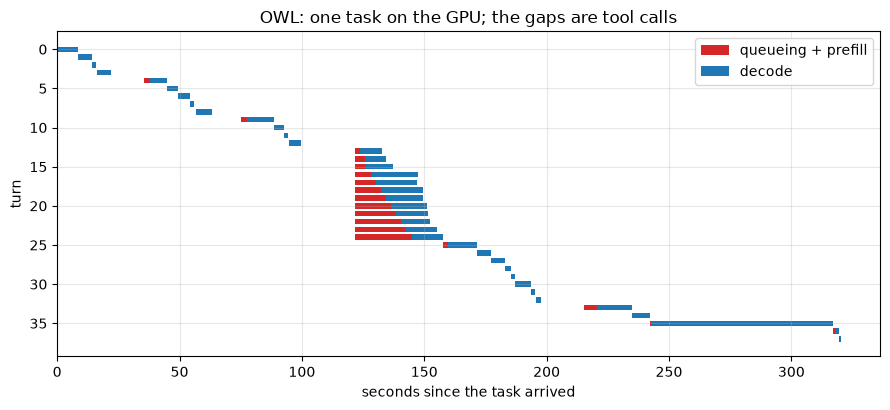

In [6]:
def timeline(df, session, title):
    """Run the trace and draw one session's turns on a wall clock."""
    trace = lsg.gaia_trace(df, name=title.split(":")[0].lower())
    r = lsg.simulate(**SYSTEM, trace=trace, num_requests=len(df), qps=0.1,
                     prefix_caching=True, max_tokens=65536)
    q = r.requests.assign(session=lambda d: d["Request Id"] // 1000,
                          turn=lambda d: d["Request Id"] % 1000)
    s = q[q.session == session].sort_values("turn")
    t0 = s.request_arrived_at.min()

    fig, ax = plt.subplots(figsize=(9, 4.2))
    for _, x in s.iterrows():
        a = x.request_arrived_at - t0
        ax.barh(x.turn, x.prefill_e2e_time, left=a, color="C3", height=.7)
        ax.barh(x.turn, x.request_e2e_time - x.prefill_e2e_time,
                left=a + x.prefill_e2e_time, color="C0", height=.7)
    ax.barh(0, 0, color="C3", label="queueing + prefill")
    ax.barh(0, 0, color="C0", label="decode")
    ax.set(xlabel="seconds since the task arrived", ylabel="turn", title=title)
    ax.legend(loc="upper right")
    ax.invert_yaxis()
    fig.tight_layout()

    sub = df[df.session == session]
    return pd.Series({
        "task completion time (s)": (s.request_arrived_at + s.request_e2e_time).max() - t0,
        "summed over its turns: decode (s)": (s.request_e2e_time - s.prefill_e2e_time).sum(),
        "summed over its turns: prefill (s)": s.prefill_time_execution_plus_preemption.sum(),
        "summed over its turns: queueing (s)": s.request_scheduling_delay.sum(),
        # Siblings released by one fan-out all waited for the same tool call, so count it once.
        "waiting for tools (s)": sub.groupby(sub.dep.map(tuple)).tool_time.max().sum(),
    }).round(1)

timeline(sessions, 4, "OWL: one task on the GPU; the gaps are tool calls")

첫째, 과제가 질의들의 사슬로 실행되는 것을 볼 수 있습니다. 대체로 순차적이지만 가끔
병렬이죠. 많은 agentic 시스템이 대체로 순차적이고, 더 병렬적인 구조를 넣으려는 시도들이
연구되고 있습니다(예: LATS,
[Zhou et al., ICML '24](https://arxiv.org/abs/2310.04406)).
둘째, 파란색(decode) 부분이 지배적인 것을 볼 수 있습니다. Prefix cache hit rate가 높고,
지금은 GPU에 다른 경쟁이 없기 때문입니다.
Prefix cache hit rate가 낮고 같은 GPU에 다른 요청이 많다면 막대의 모양은 달라질 것입니다
(2강에서 배웠듯, prefill은 decode처럼 깔끔하게 batching되지 않으니까요).
다시 말하지만, 가운데의 병렬 과제 열두 개는 OWL이 아주 긴 웹 스크랩 텍스트를, context 길이를
크게 늘리지 않으면서 요약하려는 장면입니다.

Turn별 decode 시간을 모두 더한 값(364초)이 과제 자체의 320초보다 크다는 점에 주목하세요.
일부 turn이 동시에 돌았기 때문에만 가능한 일입니다. Queueing 120초도 대부분 그 형제들이
서로를 기다린 시간입니다.

task completion time (s)               774.6
summed over its turns: decode (s)      586.5
summed over its turns: prefill (s)      68.0
summed over its turns: queueing (s)      6.8
waiting for tools (s)                  113.4
dtype: float64

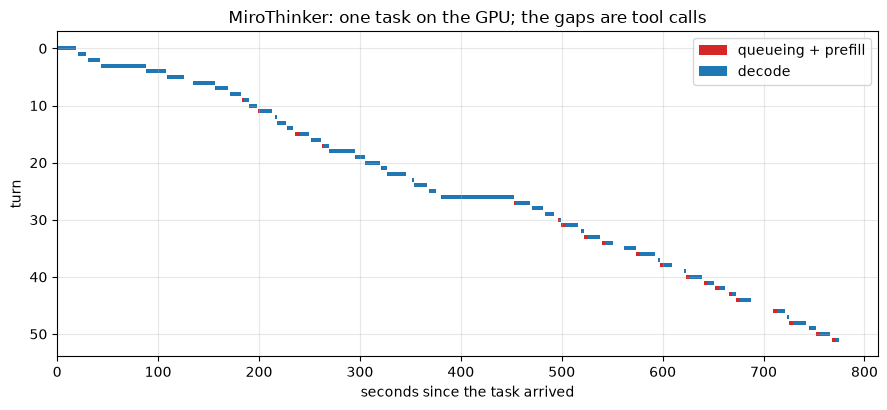

In [7]:
timeline(miro, miro.groupby("session").size().idxmax(),
         "MiroThinker: one task on the GPU; the gaps are tool calls")

단일 agent는 완전히 다르게 생겼습니다. 한 번에 하나의 요청만 떠 있으므로 막대가 계단을
이루고, decode 시간의 합(587초)은 과제의 775초보다 *작습니다*. 그 차이가 tool 시간과 agent
자신의 처리입니다. Queueing에 쓴 시간은 거의 없습니다(7초). 이 과제는 자기 자신과 경쟁할 일이
없기 때문입니다.

Serving system 입장에서 불편한 부분이 바로 여기입니다. 이 과제에서 GPU는 한 번도 문제가 아니
었습니다. 더 빠른 replica는 파란 막대를 줄일 뿐 흰 빈틈은 그대로 둡니다. 도움이 될 만한 것은
serving replica 하나가 할 수 없는 일, 즉 과제의 더 많은 부분을 동시에 돌리는 것입니다.
여기서 serving system이 할 수 있는 일은 전부 *다른* 과제에 관한 것입니다. 그 빈틈을 다른
사람의 일로 채워서, 어느 한 사용자도 답을 더 빨리 받지는 못하더라도 GPU는 바쁘게 만드는 것이죠.
{doc}`../../lectures/08-scheduling-agentic-workloads`가 그다음으로 가는 곳입니다.

:::{admonition} 직접 해보기
:class: exercise
1. OWL의 join turn(`dep`에 항목이 열두 개인 turn)이 *첫* 의존 turn이 끝난 뒤 얼마나 더
   기다리는지 재 보세요. 그중 얼마가 자기 형제들 뒤에 줄 서서 기다린 시간이고, 그것을
   줄이려면 scheduler가 무엇을 알아야 할까요?
2. MiroThinker timeline의 흰 빈틈을 모두 더해 보세요. 그 시간에 다른 과제를 처리할 수 있다면,
   replica를 계속 바쁘게 두는 데 그런 과제가 몇 개나 필요할까요?
:::

## 정리

| | 무엇을 보았나 |
|---|---|
| 재사용 가능한 prompt | OWL은 prompt token의 60%, MiroThinker는 71%. 한 agent의 대화 안에서는 87%이지만, sub-agent들 사이와 요약기 호출에서는 훨씬 낮다 |
| 누구를 재느냐가 중요하다 | 같은 시스템인데도 요약기가 trace에 들어 있느냐에 따라 87%도 되고 71%도 된다 |
| Prefix caching | TTFT는 6~10배 좋아지지만 과제 시간은 4분의 1~3분의 1만 줄어든다. Decode와 tool은 건드리지 못하기 때문이다 |
| Queueing | 형제들끼리 서로를 기다리는 fan-out에는 caching이 도움이 되지 않는다 |
| 단일 agent 과제 | 한 번에 요청 하나, queueing은 거의 없고, 오직 *다른* 과제만이 채울 수 있는 긴 빈틈이 남는다 |

## 이해도 확인

답을 눌러 확인하세요. 틀리면 다시 시도할 수 있습니다.

In [8]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "MiroThinker's main agent reaches an 87% ideal hit rate, but the system as a whole only 71%. Why?",
     "options": ["The block size is too large for the main agent",
                 "A fifth of the prompt tokens are summariser calls, each a different scraped page behind the same short instruction, which share almost nothing",
                 "The main agent's cache is evicted between turns"],
     "answer": 1,
     "explain": "Reuse follows the agent's structure. Papers that only instrument the main loop report the 87% number for the very same system."},
    {"q": "Why is OWL's hit rate (60%) lower than MiroThinker's main agent (87%)?",
     "options": ["OWL's prompts are shorter",
                 "Each OWL worker starts its own conversation with a different system prompt, and the requests of a fan-out share only their instructions",
                 "OWL was recorded with caching disabled"],
     "answer": 1,
     "explain": "Within a worker's stretch of turns almost everything repeats; across workers and across the chunks of a fan-out, much less does."},
    {"q": "Prefix caching cut TTFT by 6× but task completion time by only about a quarter. Why?",
     "options": ["The KV cache hit rate was too low",
                 "Most of a task's time is decode and tool calls, which prefix caching does not touch",
                 "Task time is dominated by queueing"],
     "answer": 1,
     "explain": "The task's critical path is a chain of turns, each spending most of its time generating tokens or waiting for a tool."},
    {"q": "Caching halved MiroThinker's p99 TTFT but left OWL's unchanged. What is OWL's tail made of?",
     "options": ["Very long prompts that miss in the cache",
                 "A fan-out of a dozen requests released at once, the last of which queues behind its siblings",
                 "Tool calls that time out"],
     "answer": 1,
     "explain": "That wait is queueing, not prefill, so making prefill cheaper does not shorten it. It needs a scheduler, which is the next lecture."},
    {"q": "A session waits 22 s for a tool. What is the dilemma for the replica holding its KV cache?",
     "options": ["Whether to keep the blocks (idle memory) or evict them (a full re-prefill when the turn returns)",
                 "Whether to decode ahead speculatively",
                 "Whether to switch the session to another model"],
     "answer": 0,
     "explain": "Tool gaps make the reuse distance long. This is the agentic version of lecture 5's eviction trade-off, and it is why cache capacity and offload matter for agents."},
])

1. MiroThinker의 main agent는 이상적인 hit rate가 87%인데 시스템 전체는 71%입니다. 왜일까요? main agent에게는 block size가 너무 커서 prompt token의 5분의 1이 요약기 호출인데, 각각이 같은 짧은 지시문 뒤에 붙은 서로 다른 스크랩 페이지라 공유할 것이 거의 없어서 turn 사이에 main agent의 cache가 evict되어서 2. OWL의 hit rate(60%)가 MiroThinker의 main agent(87%)보다 낮은 이유는? OWL의 prompt가 더 짧아서 OWL의 worker마다 서로 다른 system prompt로 자기 대화를 시작하고, fan-out의 요청들은 지시문만 공유하므로 OWL은 caching을 끈 상태로 기록되어서 3. Prefix caching이 TTFT는 6× 줄였는데 task 완료 시간은 약 4분의 1만 줄였습니다. 왜일까요? KV cache hit rate가 너무 낮아서 task 시간의 대부분이 decode와 tool 호출인데, prefix caching은 둘 다 건드리지 못하므로 task 시간을 queueing이 지배하므로 4. Caching은 MiroThinker의 p99 TTFT를 절반으로 줄였지만 OWL의 것은 그대로 두었습니다. OWL의 꼬리는 무엇으로 이루어져 있나요? cache에서 빗나가는 아주 긴 prompt 한순간에 풀려난 열두 개의 요청, 그리고 그 마지막 것이 형제들 뒤에 줄 서서 기다리는 시간 timeout이 나는 tool 호출 5. 어떤 session이 tool을 22초 기다립니다. 그 KV cache를 들고 있는 replica의 딜레마는? block을 그대로 둘지(메모리가 놀게 됨) evict할지(turn이 돌아오면 전체 re-prefill) 미리 speculative하게 decode할지 그 session을 다른 모델로 옮길지